In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [2]:
df = pd.read_csv("PreProcessed_IBM_Telco_Customer_Churn_Cleaned.csv")  
df = df.drop(columns=["customerID"])
df = df.drop(columns=["TenureGroup"])  

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1


In [3]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

print(f"Final feature matrix shape: {X.shape}")
print(y.value_counts(normalize=True))

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Final feature matrix shape: (7043, 31)
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n" + classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Accuracy : 0.7395
Precision: 0.5060
Recall   : 0.7834
F1 Score : 0.6149
ROC-AUC  : 0.8412

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



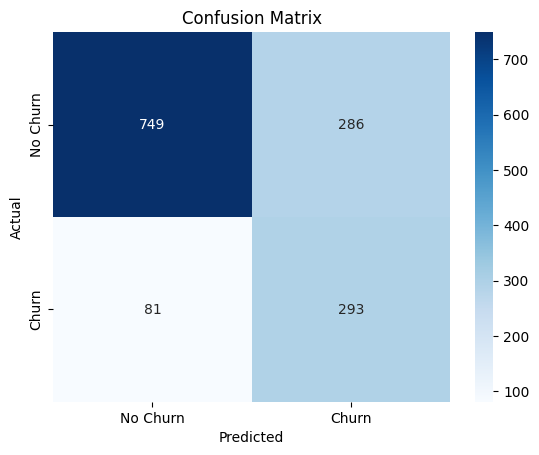

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

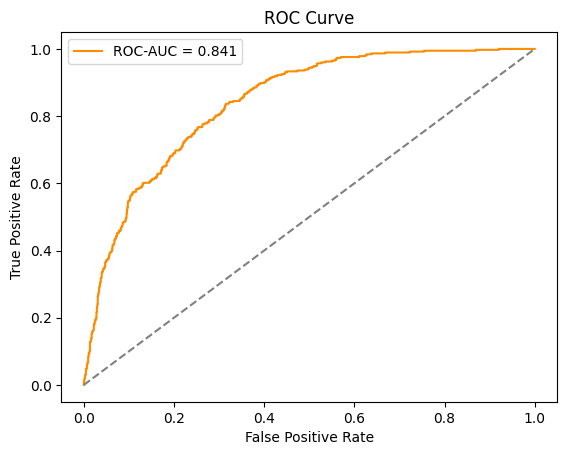

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

                       Feature  Coefficient
                        tenure    -1.140148
                MonthlyCharges    -1.040093
   InternetService_Fiber optic     0.812782
             Contract_Two year    -0.617437
                  TotalCharges     0.472907
             Contract_One year    -0.296704
           StreamingMovies_Yes     0.260301
               StreamingTV_Yes     0.247606
PaymentMethod_Electronic check     0.188690
             MultipleLines_Yes     0.175757
          PaperlessBilling_Yes     0.164645
            OnlineSecurity_Yes    -0.138378
                 TotalServices     0.112877
               TechSupport_Yes    -0.107399
                Dependents_Yes    -0.105255


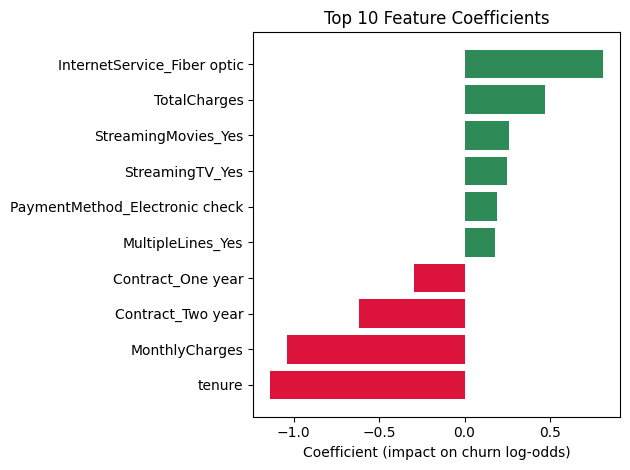

In [10]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df.head(15).to_string(index=False))

top_feats = coef_df.head(10).sort_values(by="Coefficient")
colors = ["crimson" if c < 0 else "seagreen" for c in top_feats["Coefficient"]]
plt.barh(top_feats["Feature"], top_feats["Coefficient"], color=colors)
plt.title("Top 10 Feature Coefficients")
plt.xlabel("Coefficient (impact on churn log-odds)")
plt.tight_layout()
plt.show()